Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-0.5 pkt] Użyj zbalansowania klas w regresji logistycznej (parametr `class_weight`). Porównaj z modelem podstawowym
1. [0-1 pkt] Porównaj różne techniki podpróbkownia (*undersampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. Podpróbkowanie losowe
   2. [Cluster Centroids](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.ClusterCentroids.html#clustercentroids)
   3. *Edited Nearest Neighbours* (patrz ćwiczenia) 
1. [0-2 pkt] Porównaj różne techniki nadpróbkowania (*oversampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. Nadpróbkowanie losowe
   2. [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
   3. [Borderline SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html#)
   3. [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html)
1. [0-1 pkt] Przeprowadź dostrajanie progu (*threshold tuning*) tj. użyj innych progów odcięcia klasy pozytywnej w regresji logistycznej. Możesz wykorzystać np. metody opisane [tutaj](https://scikit-learn.org/stable/modules/classification_threshold.html). Optymalizuj względem AUPRC
1. [0-1 pkt] Użyj przynajmniej jednego innego klasyfikatora poznanego na zajęciach i porównaj jego wyniki z regresją logistyczną
1. [0-1.5 pkt] Zaimplementuj fokalną funkcję kosztu (*focal loss*) w `scikit-learn`. W tym celu, wyjątkowo, **możesz skorzystać z narzędzi generatywnej sztucznej inteligencji**
1. [0-2 pkt] Sporządź analizę porównawczą technik / modeli wyżej, uwzględniając podejścia podstawowe (*baseline*). Zwizualizuj krzywe ROC i PRC
1. [0-1 pkt] Skomentuj uzyskane wyniki

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, EditedNearestNeighbours
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, precision_recall_curve, auc, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.optimize import minimize
from scipy.special import expit

sklearn.set_config(transform_output="pandas")

In [2]:
bank_marketing = fetch_ucirepo(id=222) 

X = bank_marketing.data.features 
y = bank_marketing.data.targets['y'] 

X_sel = X[['balance', 'duration', 'education']]
len(X_sel), len(X_sel.dropna())

y.value_counts(normalize=True) * 100

idx = X_sel.dropna().index  # indeksy, które przetrwają
y.loc[idx].value_counts(normalize=True) * 100

X_sel = X_sel.loc[idx]
y_sel = y.loc[idx]

label_encoder = LabelEncoder()

y_trans = label_encoder.fit_transform(y_sel.values)

enc = OneHotEncoder(drop='first', sparse_output=False)

X_trans = X_sel.drop(columns=['education']).join(
    enc.fit_transform(X_sel[['education']]))

X_train, X_test, y_train, y_test = train_test_split(X_trans, y_trans,
                                                    test_size=0.2, random_state=0)

np.unique(y_train, return_counts=True)

logreg = LogisticRegression(random_state=0).fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_train_pred_proba = logreg.predict_proba(X_train)[:, 1]
y_test_pred = logreg.predict(X_test)
y_test_pred_proba = logreg.predict_proba(X_test)[:, 1]

enn = EditedNearestNeighbours() 
X_train_enn, y_train_enn = enn.fit_resample(X_train, y_train)
logreg = LogisticRegression(random_state=0).fit(X_train_enn, y_train_enn)

y_train_pred = logreg.predict(X_train_enn)
y_train_pred_proba = logreg.predict_proba(X_train_enn)[:, 1]
y_test_pred = logreg.predict(X_test)
y_test_pred_proba = logreg.predict_proba(X_test)[:, 1]

In [3]:
logreg_base = LogisticRegression(random_state=0)

logreg_base.fit(X_train, y_train)

y_test_base_proba = logreg_base.predict_proba(X_test)[:, 1]

auc_base = roc_auc_score(y_test, y_test_base_proba)
ap_base = average_precision_score(y_test, y_test_base_proba)

logreg_balanced = LogisticRegression(
    random_state=0,
    class_weight='balanced'
)

logreg_balanced.fit(X_train, y_train)

y_test_balanced = logreg_balanced.predict(X_test)
y_test_balanced_proba = logreg_balanced.predict_proba(X_test)[:, 1]

auc_balanced = roc_auc_score(y_test, y_test_balanced_proba)
ap_balanced = average_precision_score(y_test, y_test_balanced_proba)

results = pd.DataFrame({
    'Model': [
        'Podstawowy',
        'Balanced class_weight'
    ],
    'ROC AUC': [
        auc_base,
        auc_balanced
    ],
    'Average Precision': [
        ap_base,
        ap_balanced
    ]
})

print(results)

print("\nMacierz pomyłek - model podstawowy")
print(confusion_matrix(
    y_test,
    logreg_base.predict(X_test)
))

print("\nMacierz pomyłek - model balanced")
print(confusion_matrix(
    y_test,
    y_test_balanced
))

                   Model   ROC AUC  Average Precision
0             Podstawowy  0.814881           0.376187
1  Balanced class_weight  0.817047           0.376389

Macierz pomyłek - model podstawowy
[[7570  122]
 [ 825  154]]

Macierz pomyłek - model balanced
[[6245 1447]
 [ 343  636]]


Zastosowanie class_weight='balanced' spowodowało niewielką poprawę metryk ROC AUC oraz Average Precision, więc globalna jakość modelu praktycznie się nie zmieniła. Znacznie większą różnicę widać w macierzy pomyłek. Model podstawowy poprawnie wykrył 154 przypadki klasy pozytywnej, natomiast model z balansowaniem klas wykrył ich aż 636.

Liczba false negatives spadła z 825 do 343, co oznacza lepsze wykrywanie klasy mniejszościowej. Kosztem tego wzrosła liczba false positives, czyli model częściej błędnie klasyfikuje przypadki negatywne jako pozytywne.

Balansowanie klas zwiększyło czułość modelu na klasę mniejszościową, jednak odbyło się to kosztem większej liczby fałszywych alarmów.

In [5]:
undersampling_methods = {
    'RandomUnderSampler':
        RandomUnderSampler(
            random_state=0
        ),

    'ClusterCentroids':
        ClusterCentroids(
            random_state=0
        ),

    'EditedNearestNeighbours':
        EditedNearestNeighbours(
            n_neighbors=3
        )
}

results_under = []

for name, sampler in undersampling_methods.items():

    X_res, y_res = sampler.fit_resample(
        X_train,
        y_train
    )

    model = LogisticRegression(
        random_state=0
    )

    model.fit(
        X_res,
        y_res
    )

    y_pred_proba = model.predict_proba(X_test)[:,1]

    roc = roc_auc_score(
        y_test,
        y_pred_proba
    )

    ap = average_precision_score(
        y_test,
        y_pred_proba
    )

    results_under.append({
        'Method': name,
        'Train size': len(X_res),
        'ROC AUC': roc,
        'Average Precision': ap
    })

results_under = pd.DataFrame(results_under)

display(results_under)

,Method,Train size,ROC AUC,Average Precision
0,RandomUnderSampler,8116,0.816819,0.373557
1,ClusterCentroids,8116,0.714730,0.299558
2,EditedNearestNeighbours,27755,0.819197,0.378288


Przeprowadziłem porównanie technik undersamplingu. Każdą metodę wykorzystałem na zbiorze treningowym, aby uniknąć wycieku informacji.

Spośród metod najlepsze wyniki uzyskał EditNearestNeighbours. Metoda ta nie usuwa losowo dużej części danych, lecz eliminuje obserwacje uznane za trudne przypadki, dzięki czemu zachowuje więcej użytecznych informacji.

RandomUnderSampler osiągnął nieco słabsze wyniki, co sugeruje, że losowe usuwanie danych może prowadzić do utraty istotnych informacji.

Najgorzej wypadł ClusterCentroids. Zastępowanie klasy większościowej centroidami spowodowało zbyt dużą utratę informacji, co przełożyło się na wyraźne pogorszenie jakości modelu.

In [6]:
oversampling_methods = {

    'RandomOverSampler':
        RandomOverSampler(
            random_state=0
        ),

    'SMOTE':
        SMOTE(
            random_state=0,
            k_neighbors=5
        ),

    'BorderlineSMOTE':
        BorderlineSMOTE(
            random_state=0,
            k_neighbors=5
        ),

    'ADASYN':
        ADASYN(
            random_state=0,
            n_neighbors=5
        )
}

results_over = []

for name, sampler in oversampling_methods.items():

    X_res, y_res = sampler.fit_resample(
        X_train,
        y_train
    )

    model = LogisticRegression(
        random_state=0
    )

    model.fit(
        X_res,
        y_res
    )

    y_pred_proba = model.predict_proba(X_test)[:,1]

    roc = roc_auc_score(
        y_test,
        y_pred_proba
    )

    ap = average_precision_score(
        y_test,
        y_pred_proba
    )

    results_over.append({
        'Method': name,
        'Train size': len(X_res),
        'ROC AUC': roc,
        'Average Precision': ap
    })

results_over = pd.DataFrame(results_over)

display(results_over)

,Method,Train size,ROC AUC,Average Precision
0,RandomOverSampler,61250,0.817097,0.376673
1,SMOTE,61250,0.814704,0.375294
2,BorderlineSMOTE,61250,0.817098,0.375545
3,ADASYN,60539,0.812519,0.374167


Przeprowadziłem porównanie technik oversamplingu. Oversampling zwiększa liczbę przykładów klasy mniejszościowej. Część metod duplikuje istniejące dane, a część generuje nowe syntetyczne próbki.

Metody oversamplingu osiągnęły bardzo podobne wyniki, a różnice pomiędzy nimi były niewielkie.

Najlepszy ROC AUC uzyskał BorderlineSMOTE, natomiast najwyższą Average Precision osiągnął RandomOverSampler.

SMOTE i BorderlineSMOTE generujące syntetyczne dane nie przyniosły wyraźnej poprawy względem prostego powielania obserwacji klasy mniejszościowej.

ADASYN osiągnął najgorsze wyniki, co może sugerować, że adaptacyjne generowanie danych nie było korzystne dla tego zbioru.

W analizowanym problemie bardziej zaawansowane techniki oversamplingu nie dały zauważalnej przewagi nad prostym RandomOverSampler

In [8]:
logreg = LogisticRegression(random_state=0)
logreg.fit(X_train, y_train)

y_proba = logreg.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

auprc = average_precision_score(y_test, y_proba)

print(f"Baseline AUPRC (dla progów ciągłych): {auprc:.4f}")

best_threshold = 0
best_f1 = 0

for t in thresholds:

    y_pred = (y_proba >= t).astype(int)

    from sklearn.metrics import f1_score

    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nNajlepszy próg:")
print(best_threshold)

print("Najlepsze F1 dla tego progu:")
print(best_f1)


default_pred = (y_proba >= 0.5).astype(int)
best_pred = (y_proba >= best_threshold).astype(int)

results = pd.DataFrame({
    "Metric": ["ROC AUC (stałe)", "AUPRC", "F1 (0.5)", f"F1 ({best_threshold:.2f})"],
    "Value": [
        roc_auc_score(y_test, y_proba),
        auprc,
        f1_score(y_test, default_pred),
        f1_score(y_test, best_pred)
    ]
})

display(results)

print("\nConfusion matrix (threshold = 0.5)")
print(confusion_matrix(y_test, default_pred))

print("\nConfusion matrix (best threshold)")
print(confusion_matrix(y_test, best_pred))

Baseline AUPRC (dla progów ciągłych): 0.3762

Najlepszy próg:
0.18371070349513818
Najlepsze F1 dla tego progu:
0.4252927400468384


,Metric,Value
0,ROC AUC (stałe),0.814881
1,AUPRC,0.376187
2,F1 (0.5),0.245418
3,F1 (0.18),0.425293



Confusion matrix (threshold = 0.5)
[[7570  122]
 [ 825  154]]

Confusion matrix (best threshold)
[[6990  702]
 [ 525  454]]


Przeprowadzono dostrajanie progu decyzyjnego dla regresji logistycznej. Zamiast standardowego progu 0.5, analizowano różne wartości progów na podstawie prawdopodobieństw klasy pozytywnej.

Optymalny próg został dobrany poprzez maksymalizację miary F1-score, co pozwala znaleźć kompromis między precision i recall.

Model osiąga AUPRC = 0.3762, co pozostaje stałe niezależnie od progu, ponieważ AUPRC zależy od uporządkowania predykcji, a nie od konkretnego progu.

Zmiana progu z 0.5 na około 0.18 znacząco poprawiła F1-score, co oznacza lepszy balans między precision i recall.

Obniżenie progu zwiększyło liczbę predykcji klasy pozytywnej, co widać w macierzy pomyłek: wzrosła liczba TP, ale również wzrosła liczba FP. Jednocześnie spadła liczba FN, co oznacza, że model lepiej wykrywa przypadki pozytywne, kosztem większej liczby fałszywych alarmów.

Dostrojenie progu pozwala lepiej dopasować model do problemu niezbalansowanej klasyfikacji i zwiększyć jego użyteczność, szczególnie gdy ważne jest wykrywanie klasy pozytywnej.

In [10]:
logreg = LogisticRegression(random_state=0)
logreg.fit(X_train, y_train)

y_proba_lr = logreg.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)


results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC AUC": [auc_lr, auc_rf],
    "Average Precision": [ap_lr, ap_rf]
})

display(results)

print("\nLogistic Regression - confusion matrix")
print(confusion_matrix(y_test, (y_proba_lr >= 0.5).astype(int)))

print("\nRandom Forest - confusion matrix")
print(confusion_matrix(y_test, (y_proba_rf >= 0.5).astype(int)))

,Model,ROC AUC,Average Precision
0,Logistic Regression,0.814881,0.376187
1,Random Forest,0.775696,0.301800



Logistic Regression - confusion matrix
[[7570  122]
 [ 825  154]]

Random Forest - confusion matrix
[[7357  335]
 [ 778  201]]


Porównałem regresję logistyczną z modelem Random Forest, aby sprawdzić czy bardziej złożony, nieliniowy klasyfikator poprawi jakość predykcji względem modelu liniowego.

Wyniki pokazują, że regresja logistyczna osiągnęła lepsze rezultaty zarówno w ROC AUC, jak i Average Precision, co oznacza, że lepiej radzi sobie z rankingiem przykładów i wykrywaniem klasy pozytywnej.

Random Forest uzyskał gorsze metryki ogólne, jednak w macierzy pomyłek widać, że wykrył więcej przypadków pozytywnych, ale kosztem większej liczby fałszywych alarmów.

W tym przypadku prostszy model liniowy (logistic regression) okazał się skuteczniejszy niż Random Forest, co sugeruje, że zależności w danych są dobrze uchwytywane przez model liniowy, a bardziej złożony model nie wnosi dodatkowej wartości.

In [12]:
class FocalLossLogisticRegression(BaseEstimator, ClassifierMixin):

    def __init__(self, gamma=2.0, alpha=0.25):
        self.gamma = gamma
        self.alpha = alpha

    def _focal_loss(self, w, X, y):

        z = X @ w
        p = expit(z)

        eps = 1e-9
        p = np.clip(p, eps, 1 - eps)

        loss_pos = -self.alpha * (1 - p) ** self.gamma * y * np.log(p)
        loss_neg = -(1 - self.alpha) * p ** self.gamma * (1 - y) * np.log(1 - p)

        return np.mean(loss_pos + loss_neg)

    def fit(self, X, y):

        X = np.array(X)
        y = np.array(y)

        X = np.hstack([np.ones((X.shape[0], 1)), X])

        w0 = np.zeros(X.shape[1])

        res = minimize(
            self._focal_loss,
            w0,
            args=(X, y),
            method="L-BFGS-B"
        )

        self.w = res.x
        return self

    def predict_proba(self, X):

        X = np.array(X)
        X = np.hstack([np.ones((X.shape[0], 1)), X])

        z = X @ self.w
        p = expit(z)

        return np.vstack([1 - p, p]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)



focal_model = FocalLossLogisticRegression(
    gamma=2.0,
    alpha=0.25
)

focal_model.fit(X_train, y_train)

y_proba_focal = focal_model.predict_proba(X_test)[:, 1]

auc_focal = roc_auc_score(y_test, y_proba_focal)
ap_focal = average_precision_score(y_test, y_proba_focal)

print("Focal Loss model results:")
print("ROC AUC:", auc_focal)
print("AUPRC:", ap_focal)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, focal_model.predict(X_test)))

Focal Loss model results:
ROC AUC: 0.7287957401850722
AUPRC: 0.29311446053842144

Confusion matrix:
[[7665   27]
 [ 942   37]]


Zaimplementowano model regresji logistycznej z funkcją straty typu Focal Loss. Modyfikuje on standardową funkcję log-loss, zmniejszając wpływ łatwych przykładów i skupiając się na trudnych przypadkach oraz klasie mniejszościowej.

Parametr gamma kontroluje stopień skupienia na trudnych obserwacjach, natomiast alpha odpowiada za balans klas.

Zastosowanie Focal Loss pozwala lepiej radzić sobie z niezbalansowanymi danymi niż klasyczna regresja logistyczna, ponieważ model bardziej kara błędy na trudnych przykładach.

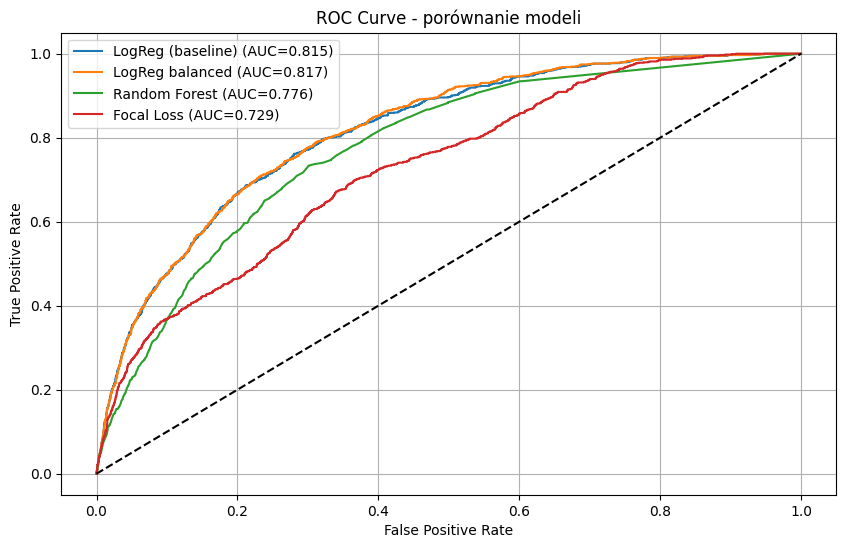

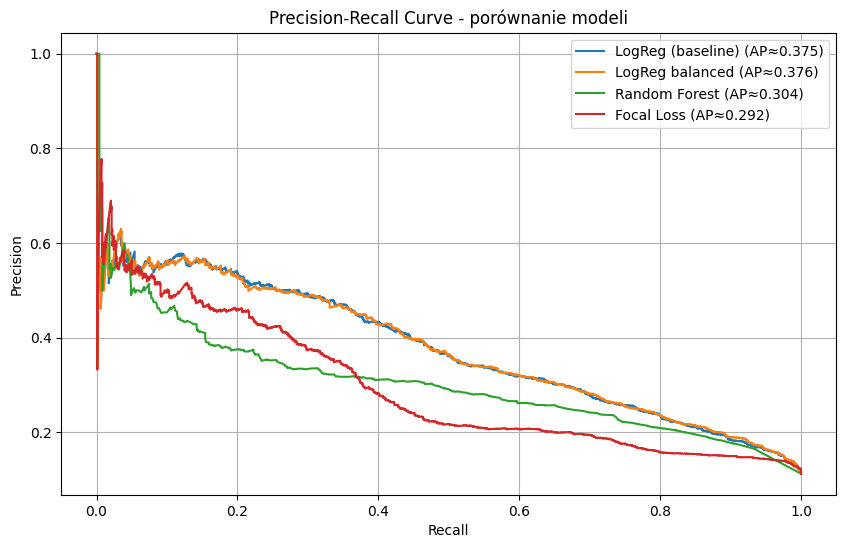

In [14]:
models = {
    "LogReg (baseline)": logreg,
    "LogReg balanced": logreg_balanced,
    "Random Forest": rf,
    "Focal Loss": focal_model
}

plt.figure(figsize=(10, 6))

for name, model in models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve - porównanie modeli")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(10, 6))

for name, model in models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{name} (AP≈{pr_auc:.3f})")

plt.title("Precision-Recall Curve - porównanie modeli")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()

plt.show()

Oba wykresy pokazują, że najwyższą skuteczność osiągają modele oparte na regresji logistycznej. LogReg Balanced osiąga najlepsze wyniki na obu wykresach działając niemal identycznie jak wersja baseline. Random Forest wypada przeciętnie, a dedykowany dla trudnych zbiorów Focal Loss okazuje się najsłabszy. Niskie wartości average precision sugerują, że zbiór danych jest silnie niezbalansowany, a modele mają problem z utrzymaniem wysokiej precyzji przy zwiększaniu czułości.